Importamos librerías

In [49]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn import svm, datasets
from sklearn.metrics import accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')

Cargamos dataset de train y analizamos

In [50]:
df = pd.read_csv("data/jm_train.csv", index_col=0)
df.reset_index(inplace=True)
df.head()

,feature1,feature2,feature3,feature4,feature5,feature6,target
0,0.474335,0.881640,-2.050543,-1.251935,-1.035151,-1.934367,4
1,-1.034675,1.741801,-1.660629,-1.555989,-0.337553,-2.473838,0
2,-0.563221,-0.688381,-0.318415,-1.845172,0.352366,-0.912928,1
3,-1.268179,2.770688,1.054193,2.830389,0.395093,0.677715,3
4,-1.216380,-0.391267,-2.898931,-0.913074,-2.171857,-2.367490,0


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2100 entries, 0 to 2099
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   feature1  2100 non-null   float64
 1   feature2  2100 non-null   float64
 2   feature3  2100 non-null   float64
 3   feature4  2100 non-null   float64
 4   feature5  2100 non-null   float64
 5   feature6  2100 non-null   float64
 6   target    2100 non-null   int64  
dtypes: float64(6), int64(1)
memory usage: 115.0 KB


In [52]:
# No se observan valores tipo object que tengamos que convertir

In [53]:
df.describe()

,feature1,feature2,feature3,feature4,feature5,feature6,target
count,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000
mean,-0.204656,0.199249,-0.378140,-0.206425,-0.186419,-0.433229,1.980476
std,1.543613,1.614024,1.450548,1.442225,1.501573,1.188791,1.410537
min,-6.683655,-5.383371,-6.147055,-5.653594,-5.912521,-4.433189,0.000000
25%,-1.171340,-0.877386,-1.365990,-1.259403,-1.211685,-1.131944,1.000000
50%,-0.443868,0.320507,-0.439745,-0.176504,-0.195751,-0.406754,2.000000
75%,0.890023,1.321430,0.662898,0.866879,0.851843,0.348593,3.000000
max,4.565547,6.700133,4.157518,4.371912,5.068783,4.016324,4.000000


In [54]:
df.isnull().sum()

feature1    0
feature2    0
feature3    0
feature4    0
feature5    0
feature6    0
target      0
dtype: int64

In [55]:
# No se observan valores nulos

<AxesSubplot:>

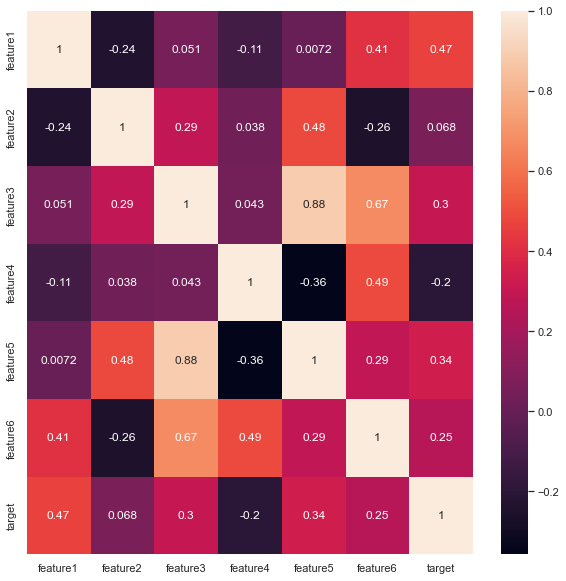

In [56]:
sns.set(rc={'figure.figsize':(10,10)})
sns.heatmap(df.corr(), annot=True)

In [57]:
# Aunque feature 4 no correla bien con nuestra target, no lo quitaremos ya que el valor -0.2 no es demasiado bajo

Spliteamos entre train y test en dataset de train para realizar pruebas

In [58]:
y = df['target']
X = df.drop('target', axis=1)

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                   test_size = 0.2,
                                                   random_state = 42)

Realizamos GridSearch para hallar los mejores parámetros del RandomForest

In [60]:
pipe = Pipeline(steps=[
    ('classifier', RandomForestClassifier())
])

random_forest_params = {
    'classifier': [RandomForestClassifier(n_jobs=-1)],
    'classifier__max_features': [1,2,3,4,5,6,7],
    'classifier__n_estimators':[100, 200, 300],
    'classifier__criterion': ['gini', 'entropy']
}

clf = GridSearchCV(estimator = pipe,
                  param_grid = random_forest_params,
                  cv = 10,  n_jobs=-1)

clf.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('classifier',
                                        RandomForestClassifier())]),
             n_jobs=-1,
             param_grid={'classifier': [RandomForestClassifier(max_features=3,
                                                               n_estimators=300,
                                                               n_jobs=-1)],
                         'classifier__criterion': ['gini', 'entropy'],
                         'classifier__max_features': [1, 2, 3, 4, 5, 6, 7],
                         'classifier__n_estimators': [100, 200, 300]})

In [61]:
print(clf.best_estimator_)
print(clf.best_score_)
print(clf.best_params_)

Pipeline(steps=[('classifier',
                 RandomForestClassifier(max_features=3, n_estimators=300,
                                        n_jobs=-1))])
0.7738095238095237
{'classifier': RandomForestClassifier(max_features=3, n_estimators=300, n_jobs=-1), 'classifier__criterion': 'gini', 'classifier__max_features': 3, 'classifier__n_estimators': 300}


Entrenamos el modelo con los mejores parámetros

In [62]:
rnd_clf = RandomForestClassifier(n_estimators = 200, max_features=3, criterion='gini', n_jobs=-1) 

rnd_clf.fit(X_train, y_train)

y_pred = rnd_clf.predict(X_test)
accuracy_score(y_test, y_pred)
f1_score(y_test, y_pred, average = 'macro')

0.7976758118973796

Volvemos a diferenciar entre el dataset train y el de test

In [63]:
y_train = df['target']
X_train = df.drop('target', axis=1)

In [64]:
df_test = pd.read_csv("data/jm_X_test.csv", index_col=0)
df_test.reset_index(inplace=True)
df_test.head()

,feature1,feature2,feature3,feature4,feature5,feature6
0,0.943723,-2.985473,-0.938218,3.580261,-3.038106,2.080338
1,-0.899819,1.295568,1.274513,0.718186,1.117035,0.463068
2,0.293281,-0.099317,1.874902,-0.589582,1.828441,1.011596
3,-1.134804,0.888585,-1.464499,-1.183056,-0.525729,-1.963822
4,-0.909240,1.575797,0.697212,1.197092,0.486185,0.222644


In [65]:
X_test = df_test

Ejecutamos el modelo

In [66]:
rnd_clf = RandomForestClassifier(n_estimators = 300, max_features=3, criterion='entropy', n_jobs=-1) 

rnd_clf.fit(X_train, y_train)
y_pred = rnd_clf.predict(X_test)
y_pred

array([1, 3, 2, 0, 3, 2, 4, 0, 2, 3, 1, 4, 1, 1, 4, 4, 4, 3, 2, 0, 1, 2,
       3, 0, 0, 3, 0, 2, 2, 4, 2, 2, 4, 3, 3, 1, 0, 4, 3, 0, 4, 2, 3, 2,
       2, 0, 0, 1, 2, 4, 4, 0, 2, 0, 4, 4, 1, 3, 3, 0, 3, 0, 3, 0, 4, 1,
       1, 0, 2, 3, 0, 1, 4, 0, 4, 0, 0, 1, 0, 3, 4, 3, 1, 3, 1, 1, 2, 3,
       1, 2, 2, 4, 1, 1, 0, 1, 4, 2, 0, 4, 0, 0, 0, 4, 2, 4, 4, 4, 1, 2,
       4, 1, 3, 3, 3, 3, 3, 4, 2, 2, 0, 4, 4, 3, 3, 2, 4, 1, 3, 2, 2, 1,
       4, 0, 0, 2, 3, 0, 0, 4, 0, 4, 3, 2, 1, 3, 4, 3, 4, 4, 1, 2, 1, 2,
       0, 4, 2, 2, 4, 2, 0, 2, 3, 3, 1, 4, 1, 3, 2, 0, 1, 2, 4, 4, 1, 2,
       3, 0, 3, 4, 2, 1, 0, 2, 2, 2, 0, 3, 4, 1, 1, 1, 2, 4, 0, 0, 4, 4,
       1, 2, 0, 2, 4, 3, 2, 2, 3, 1, 1, 3, 0, 0, 2, 1, 1, 3, 4, 2, 2, 1,
       2, 3, 2, 0, 3, 2, 0, 2, 2, 3, 0, 2, 4, 3, 2, 4, 0, 3, 3, 3, 1, 4,
       3, 0, 2, 0, 2, 1, 2, 0, 2, 3, 1, 3, 1, 1, 0, 3, 2, 4, 2, 1, 0, 2,
       2, 4, 2, 4, 1, 2, 1, 4, 4, 0, 3, 0, 1, 4, 2, 4, 1, 1, 2, 1, 1, 4,
       0, 0, 2, 2, 3, 1, 0, 2, 0, 0, 4, 4, 1, 3, 0,

In [67]:
# Cargamos el ejemplo para imitarlo
ej = pd.read_csv('data/ejemplo_predicciones.csv')
ej.head()

,final_status
0,1
1,1
2,1
3,1
4,1


Creamos el DataFrame y lo guardamos

In [68]:
prediction = pd.DataFrame()
prediction['final_status'] = y_pred
prediction

,final_status
0,1
1,3
2,2
3,0
4,3
...,...
895,3
896,4
897,0
898,3


In [69]:
prediction.to_csv("prediction.csv", index = False)